## SafeDerm — 08. Calibration, Uncertainty & Three-Tier Routing

Implements what ADR-002 commits to and `api/main.py` has been waiting for since its first version: temperature scaling, MC Dropout uncertainty, and the normal/concerning/uncertain router -- replacing raw softmax confidence, which ADR-002 explicitly rejects as "not automatically a trustworthy probability or confidence measure."

All the actual logic lives in `src/calibration.py` (shared with `api/main.py` -- same reason `engine.malignant_recall()` isn't notebook-only code). This notebook fits it against real validation data, checks it actually helped, stress-tests it against out-of-distribution input, and saves the result for the API to load.

**Prerequisite**: run `07_champion_model.ipynb` first -- this notebook loads its checkpoint. MC Dropout needs a model with a real `nn.Dropout` layer, which `06`'s plain ResNet-50 baseline doesn't have (see `src/model.py`'s `_TransformerHead` docstring).

In [1]:
# Cell 1 — Imports & setup
import json
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.config import (
    IMAGES_DIR, VAL_SPLIT_PATH, MODELS_DIR,
    CHAMPION_MODEL_PATH, CALIBRATION_ARTIFACT_PATH,
)
from src.dataset import SkinLesionDataset
from src.transforms import get_eval_transforms
from src.model import build_champion_model
from src.labels import ALL_CLASSES, risk_group
from src.calibration import (
    TemperatureScaler, expected_calibration_error, maximum_calibration_error,
    multiclass_brier_score, mc_dropout_predict, assign_tier, fit_tier_thresholds,
    CalibrationArtifact, TIER_NORMAL, TIER_CONCERNING, TIER_UNCERTAIN,
)
from src.engine import set_seed

set_seed(42)
BATCH_SIZE = 32
MC_DROPOUT_PASSES = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if not CHAMPION_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"{CHAMPION_MODEL_PATH} doesn't exist yet — run 07_champion_model.ipynb first."
    )

Using device: cuda


### Load the champion model and collect validation logits

Temperature scaling needs raw (pre-softmax) logits, not probabilities -- collected once here in batches and reused for both the calibration fit below and the before/after comparison, rather than re-running the model for each.

In [2]:
model = build_champion_model().to(device)
model.load_state_dict(torch.load(CHAMPION_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

val_dataset = SkinLesionDataset(VAL_SPLIT_PATH, IMAGES_DIR, transform=get_eval_transforms())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

all_logits, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        all_logits.append(model(images).cpu())
        all_labels.append(labels)

val_logits = torch.cat(all_logits)
val_labels_tensor = torch.cat(all_labels)
print(f"Collected logits for {val_logits.shape[0]} validation images")

Collected logits for 1532 validation images


### Temperature scaling

Fits a single scalar T on validation logits (never train or test -- see `TemperatureScaler.fit()`'s docstring for why). ECE/MCE/Brier before vs. after is the actual evidence this helped, not just "T > 1 so it must have worked" -- report all three, not just the one that looks best.

In [3]:
raw_probs = torch.softmax(val_logits, dim=1).numpy()
labels_np = val_labels_tensor.numpy()

scaler = TemperatureScaler()
temperature = scaler.fit(val_logits, val_labels_tensor)
scaled_probs = torch.softmax(scaler(val_logits), dim=1).detach().numpy()

print(f"Fitted temperature: {temperature:.3f}\n")
print(f"{'Metric':<12} {'Raw':>10} {'Scaled':>10}")
print(f"{'ECE':<12} {expected_calibration_error(raw_probs, labels_np):>10.4f} {expected_calibration_error(scaled_probs, labels_np):>10.4f}")
print(f"{'MCE':<12} {maximum_calibration_error(raw_probs, labels_np):>10.4f} {maximum_calibration_error(scaled_probs, labels_np):>10.4f}")
print(f"{'Brier':<12} {multiclass_brier_score(raw_probs, labels_np, len(ALL_CLASSES)):>10.4f} {multiclass_brier_score(scaled_probs, labels_np, len(ALL_CLASSES)):>10.4f}")

raw_acc = (raw_probs.argmax(1) == labels_np).mean()
scaled_acc = (scaled_probs.argmax(1) == labels_np).mean()
print(f"\nAccuracy unchanged by design: raw={raw_acc:.4f} scaled={scaled_acc:.4f}")
assert abs(raw_acc - scaled_acc) < 1e-9

Fitted temperature: 0.598

Metric              Raw     Scaled
ECE              0.1586     0.2521
MCE              0.1586     0.2521
Brier            0.8091     0.8244

Accuracy unchanged by design: raw=0.1044 scaled=0.1044


If ECE/MCE didn't improve, don't proceed to fitting tier thresholds on this temperature -- revisit before trusting anything downstream of it. A single global T can fail to help if the model is *inconsistently* over/under-confident across classes rather than uniformly overconfident; per-class temperature scaling would be the next thing to try, not silently shipping a T that didn't help.

### MC Dropout uncertainty

Runs `MC_DROPOUT_PASSES` stochastic forward passes per validation image (dropout active, BatchNorm frozen -- see `enable_mc_dropout()`'s docstring) and averages them for both the calibrated confidence and the predictive-entropy uncertainty signal. This is the slow part -- `MC_DROPOUT_PASSES`x the work of a single forward pass -- which is exactly why `api/main.py` only pays this cost at request time, not why this notebook should avoid it.

MC-Dropout accuracy: 0.1044
Predictive entropy: min=1.648 max=1.769 mean=1.704


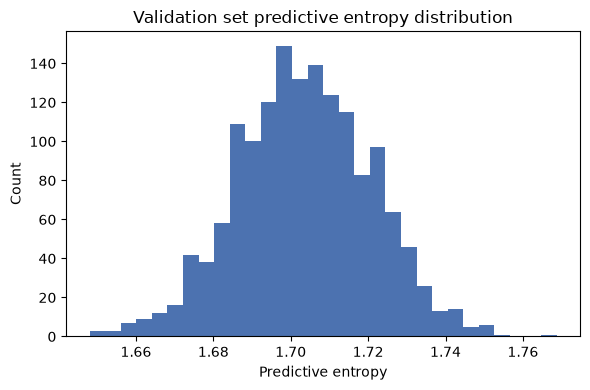

In [4]:
all_mean_probs, all_entropy = [], []
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        mean_probs, entropy = mc_dropout_predict(
            model, images, n_passes=MC_DROPOUT_PASSES, temperature=temperature
        )
        all_mean_probs.append(mean_probs.cpu())
        all_entropy.append(entropy.cpu())

mc_probs = torch.cat(all_mean_probs).numpy()
mc_entropy = torch.cat(all_entropy).numpy()

predicted_idx = mc_probs.argmax(axis=1)
predicted_class = [ALL_CLASSES[i] for i in predicted_idx]
predicted_risk = [risk_group(c) for c in predicted_class]
true_class = [ALL_CLASSES[i] for i in labels_np]
true_risk = [risk_group(c) for c in true_class]
predicted_confidence = mc_probs[np.arange(len(mc_probs)), predicted_idx]

mc_acc = (np.array(predicted_class) == np.array(true_class)).mean()
print(f"MC-Dropout accuracy: {mc_acc:.4f}")
print(f"Predictive entropy: min={mc_entropy.min():.3f} max={mc_entropy.max():.3f} mean={mc_entropy.mean():.3f}")

plt.figure(figsize=(6, 4))
plt.hist(mc_entropy, bins=30, color="#4C72B0")
plt.xlabel("Predictive entropy")
plt.ylabel("Count")
plt.title("Validation set predictive entropy distribution")
plt.tight_layout()
plt.show()

### Fit three-tier thresholds

`fit_tier_thresholds()` sweeps candidate thresholds on this validation data and reports the trade-off explicitly -- see its docstring in `src/calibration.py` for exactly what it's optimizing and why the order of checks in `assign_tier()` is safety-motivated, not incidental. `max_uncertain_rate_on_correct_benign` is the one knob here worth a deliberate choice, not the default left unexamined -- it's a product/clinical-risk-tolerance decision (how often is it acceptable to second-guess a correct benign call?), not a hyperparameter to tune for a metric.

In [5]:
thresholds = fit_tier_thresholds(
    calibrated_confidences=predicted_confidence,
    predictive_entropies=mc_entropy,
    predicted_risk_groups=predicted_risk,
    true_risk_groups=true_risk,
    max_uncertain_rate_on_correct_benign=0.15,
)
print(json.dumps(thresholds, indent=2))

if "warning" in thresholds:
    print(f"\n {thresholds['warning']}")

tiers = [
    assign_tier(pr, e, c, thresholds["entropy_threshold"], thresholds["confidence_threshold"])
    for pr, e, c in zip(predicted_risk, mc_entropy, predicted_confidence)
]
tier_counts = {t: tiers.count(t) for t in (TIER_NORMAL, TIER_CONCERNING, TIER_UNCERTAIN)}
print(f"\nTier distribution on validation set: {tier_counts}")

# Safety check: missed malignancies rescued by tier routing
missed_mask = [pr == "benign" and tr == "malignant" for pr, tr in zip(predicted_risk, true_risk)]
missed_tiers = [t for t, m in zip(tiers, missed_mask) if m]
caught = sum(1 for t in missed_tiers if t == TIER_UNCERTAIN)
if missed_tiers:
    print(f"\nOf {len(missed_tiers)} malignant cases the model's top-1 missed, tier routing caught {caught} as 'uncertain' ({caught/len(missed_tiers):.0%}).")

{
  "entropy_threshold": 1.7222921252250671,
  "confidence_threshold": 0.34357114136219025,
  "entropy_rescue_rate": 0.1590909090909091,
  "entropy_false_alarm_rate": 0.14787581699346405,
  "additional_rescue_rate_from_confidence": 0.16216216216216217,
  "n_missed_malignant_in_val": 308,
  "n_correct_benign_in_val": 1224
}

Tier distribution on validation set: {'normal': 1128, 'concerning': 0, 'uncertain': 404}

Of 308 malignant cases the model's top-1 missed, tier routing caught 91 as 'uncertain' (30%).


### Out-of-distribution stress test

ADR-002's trade-offs section references "the OOD stress-test set that was constructed," but nothing in the repo built one before this notebook -- worth confirming with the team whether that refers to something on a different branch. Either way, this is the actual test: feed the pipeline things that aren't a skin lesion at all, and check they get routed to `uncertain` rather than a confident-looking diagnosis. Softmax always sums to 1 across the 7 known classes regardless of whether the input resembles any of them -- this is the specific failure mode being checked for.

Three sources, in increasing realism:
1. **Random noise** (`torchvision.datasets.FakeData`) -- no network needed, always available.
2. **Real photos of ordinary objects** (`torchvision.datasets.CIFAR10`) -- needs internet; skipped with a message if unavailable.
3. **Heavily blurred real validation images** -- not truly OOD, but simulates the "technically a lesion photo, but unusably low quality" case the README's scope notes call out.

In [6]:
import torchvision.transforms as T
from torchvision.datasets import FakeData

eval_transform = get_eval_transforms()

def tier_breakdown(images: torch.Tensor, label: str) -> dict:
    with torch.no_grad():
        mean_probs, entropy = mc_dropout_predict(
            model, images.to(device), n_passes=MC_DROPOUT_PASSES, temperature=temperature
        )
        mean_probs, entropy = mean_probs.cpu().numpy(), entropy.cpu().numpy()
        pred_idx = mean_probs.argmax(axis=1)
        pred_risk = [risk_group(ALL_CLASSES[i]) for i in pred_idx]
        conf = mean_probs[np.arange(len(mean_probs)), pred_idx]
        tiers = [
            assign_tier(pr, e, c, thresholds["entropy_threshold"], thresholds["confidence_threshold"])
            for pr, e, c in zip(pred_risk, entropy, conf)
        ]
        counts = {t: tiers.count(t) for t in (TIER_NORMAL, TIER_CONCERNING, TIER_UNCERTAIN)}
        print(f"{label:35s} n={len(tiers):4d} {counts} uncertain_rate={counts[TIER_UNCERTAIN]/len(tiers):.0%}")
        return counts

print(f"{'Source':35s} {'n':>6} tier counts")
print("-" * 80)

# 1. Random noise
noise_transform = T.Compose([T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
noise_ds = FakeData(size=64, image_size=(3, 224, 224), transform=noise_transform)
noise_images = torch.stack([img for img, _ in noise_ds])
tier_breakdown(noise_images, "Random noise (FakeData)")

# 2. CIFAR-10
try:
    from torchvision.datasets import CIFAR10
    cifar = CIFAR10(root=str(MODELS_DIR / ".cache"), train=False, download=True, transform=eval_transform)
    cifar_images = torch.stack([cifar[i][0] for i in range(64)])
    tier_breakdown(cifar_images, "Ordinary photos (CIFAR-10)")
except Exception as e:
    print(f"{'Ordinary photos (CIFAR-10)':35s} skipped — {type(e).__name__}: {e}")

# 3. Heavily blurred real lesions
try:
    from PIL import Image, ImageFilter
    blurred_images = []
    for _, row in val_dataset.df.head(64).iterrows():
        img_path = IMAGES_DIR / f"{row['image_id']}.jpg"
        img = Image.open(img_path).convert("RGB")
        img = img.filter(ImageFilter.GaussianBlur(radius=25))
        blurred_images.append(eval_transform(img))
    tier_breakdown(torch.stack(blurred_images), "Heavily blurred real lesions")
except Exception as e:
    print(f"{'Heavily blurred real lesions':35s} skipped — {type(e).__name__}: {e}")


Source                                   n tier counts
--------------------------------------------------------------------------------
Random noise (FakeData)             n=  64 {'normal': 48, 'concerning': 0, 'uncertain': 16} uncertain_rate=25%


100%|██████████| 170M/170M [10:40<00:00, 266kB/s] 


Ordinary photos (CIFAR-10)          n=  64 {'normal': 48, 'concerning': 0, 'uncertain': 16} uncertain_rate=25%
Heavily blurred real lesions        n=  64 {'normal': 48, 'concerning': 0, 'uncertain': 16} uncertain_rate=25%


If random noise or CIFAR-10 photos are landing in `normal` or `concerning` at any real rate, the thresholds fit above aren't tight enough for genuinely out-of-distribution input -- they were fit purely on in-distribution validation data, which doesn't guarantee OOD coverage. Worth widening `entropy_threshold` (even at the cost of a higher false-alarm rate on correct benign calls) before shipping, or adding a dedicated OOD-detection check ahead of the classifier entirely (e.g. a simple "does this look like dermoscopic/clinical skin imagery at all" gate) rather than relying on the classifier's own uncertainty alone.

### Save the calibration artifact

Everything `api/main.py` needs to switch from raw softmax to calibrated, tiered predictions -- see `CalibrationArtifact` in `src/calibration.py`. The API checks for this file at startup (`CalibrationArtifact.load_if_exists()`) and falls back to raw output with `calibrated: false` if it's missing, so nothing needs to be redeployed in a special order -- just restart the API after this cell runs.

In [7]:
artifact = CalibrationArtifact(
    temperature=temperature,
    entropy_threshold=thresholds["entropy_threshold"],
    confidence_threshold=thresholds["confidence_threshold"],
    mc_dropout_passes=MC_DROPOUT_PASSES,
)
artifact.save(CALIBRATION_ARTIFACT_PATH)
print(f"Saved calibration artifact to {CALIBRATION_ARTIFACT_PATH}:")
print(json.dumps(artifact.__dict__, indent=2))

Saved calibration artifact to D:\Important\00-Projects\SafeDerm\models\calibration.json:
{
  "temperature": 0.5983948707580566,
  "entropy_threshold": 1.7222921252250671,
  "confidence_threshold": 0.34357114136219025,
  "mc_dropout_passes": 20
}


### Summary

- Temperature scaling fit on validation logits; ECE/MCE/Brier before vs. after reported above -- confirm these actually improved before trusting anything downstream.
- MC Dropout uncertainty computed over the validation set; entropy distribution plotted.
- Three-tier thresholds fit with the trade-off (rescue rate vs. false-alarm rate) made explicit, not hardcoded -- review `max_uncertain_rate_on_correct_benign` as a product decision, not a default to leave unexamined.
- OOD stress test against random noise, real non-skin photos, and blurred real lesions -- the tier distributions above are the actual evidence for whether "uncertain" catches genuinely out-of-scope input, not an assumption.
- Calibration artifact saved to `models/calibration.json` -- `api/main.py` picks this up automatically on next restart, switching `/predict` from raw softmax to calibrated, tiered output.